# Day 2 – Image Processing Techniques

   Here you'll learn the different kind image processing techniques 
   such as :
   
     1. Image Color Conversion
     2. Resizing an Image
     3. Flipping an Image
     4. Cropping an Image
     5. Translation : Shifting the Image
     6. Rotating the Image
     7. Drawing on Image
     8. Creating Black, White, Gray Images
     9. Bitwise Operation on Image

#### Loading Libraries

In [156]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

####  NOTE :

    By Default :
       1) OpenCV understands and stores images in BGR Format
       2) Matplotlib understands and display images in RGB Format
    

#### Loading and Reading Image

In [158]:
img = cv2.imread("my_car.jpeg")

#### Displaying the image

In [166]:
cv2.imshow("Car Image", img)
cv2.waitKey(6000)
cv2.destroyAllWindows()

#### Displaying the image with matplotlib

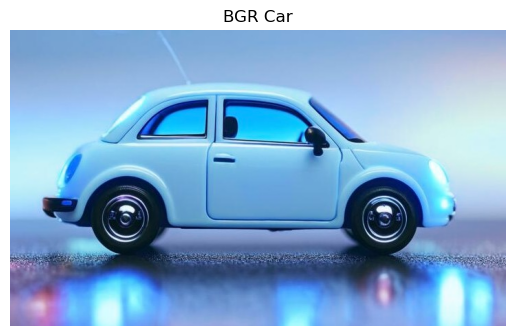

In [164]:
plt.imshow(img) # without conversion in rgb 
plt.title("BGR Car")
plt.axis('off')
plt.show()

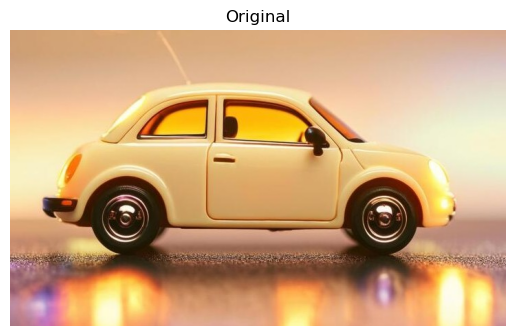

In [168]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) # matplotlib understand rgb that why we have converted bgr to rgb
plt.title("Original")
plt.axis('off')
plt.show()

##

## Image Conversion - Converting to Different Color Spaces

       Ex. Converting to grayscale image

#

## BGR to Grayscale

In [170]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

cv2.imshow("Image", gray)
cv2.waitKey(3000)
cv2.destroyAllWindows()

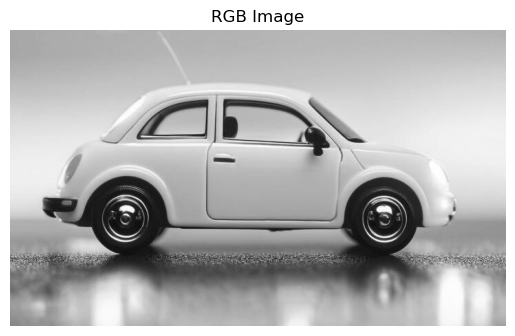

In [172]:
plt.imshow(gray , cmap = 'gray')
plt.title("RGB Image")
plt.axis('off')
plt.show()

## BGR to RGB

In [176]:
		
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2.imshow("Image", rgb)
cv2.waitKey(3000)
cv2.destroyAllWindows()

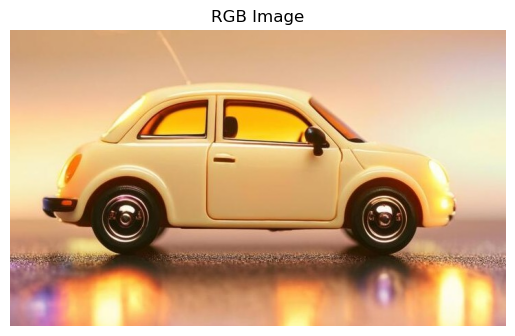

In [178]:
plt.imshow(rgb)
plt.title("RGB Image")
plt.axis('off')
plt.show()

In [180]:
img.shape

(430, 721, 3)

### Resizing the image

In [194]:
resized_img = cv2.resize(img, (800, 1000))

cv2.imshow("Image",resized_img )
cv2.waitKey(3000)
cv2.destroyAllWindows()


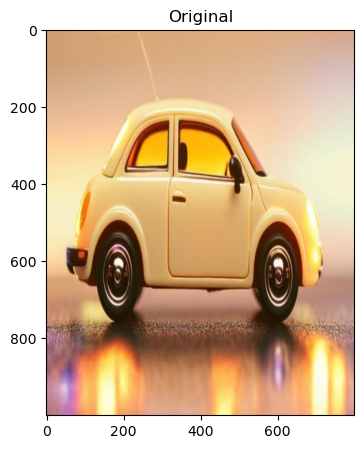

In [196]:
plt.figure(figsize=(20,5))
#plt.subplot(1,1,1)
plt.imshow(cv2.cvtColor(resized_img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.show()

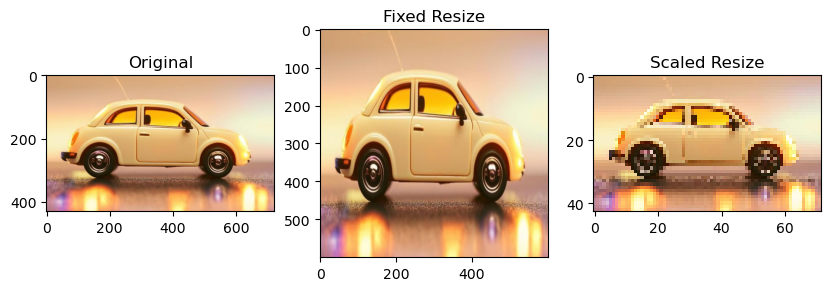

In [200]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Step 1: Read the image
img = cv2.imread('my_car.jpeg')

# Step 2: Resize using fixed size
resized_img = cv2.resize(img, (600, 600))

# Step 3: Resize using scaling factor
scaled_img = cv2.resize(img, None, fx=0.1, fy=0.1)

# Step 4: Convert BGR to RGB (for matplotlib display)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
resized_rgb = cv2.cvtColor(resized_img, cv2.COLOR_BGR2RGB)
scaled_rgb = cv2.cvtColor(scaled_img, cv2.COLOR_BGR2RGB)

# Step 5: Display
plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(resized_rgb)
plt.title("Fixed Resize")

plt.subplot(1,3,3)
plt.imshow(scaled_rgb)
plt.title("Scaled Resize")

plt.show()


### Flipping an Image 

    1. Horizontal Flip
    2. Vertical Flip
    3. Combination of both

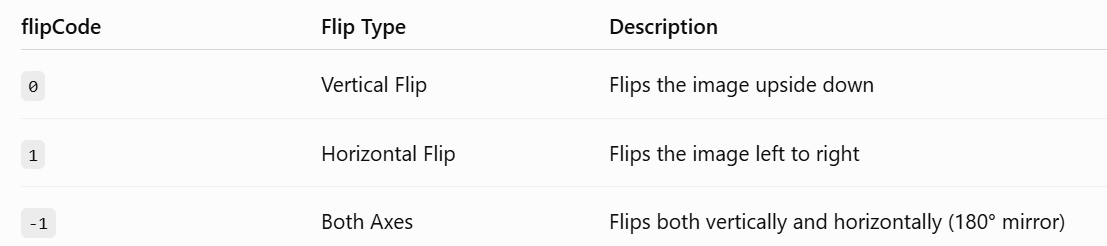
    

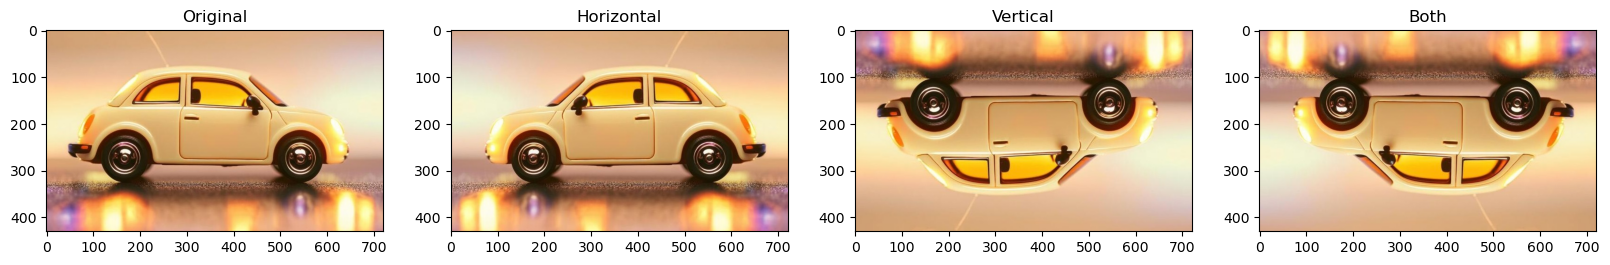

In [216]:
img = cv2.imread('my_car.jpeg')

horizontal = cv2.flip(img, 1)
vertical = cv2.flip(img, 0)
both = cv2.flip(img, -1)

plt.figure(figsize=(20,5))

plt.subplot(1,4,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")

plt.subplot(1,4,2)
plt.imshow(cv2.cvtColor(horizontal, cv2.COLOR_BGR2RGB))
plt.title("Horizontal")

plt.subplot(1,4,3)
plt.imshow(cv2.cvtColor(vertical, cv2.COLOR_BGR2RGB))
plt.title("Vertical")

plt.subplot(1,4,4)
plt.imshow(cv2.cvtColor(both, cv2.COLOR_BGR2RGB))
plt.title("Both")

plt.show()


### Cropping the image

Image Shape: (430, 721, 3)


error: OpenCV(4.9.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:196: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


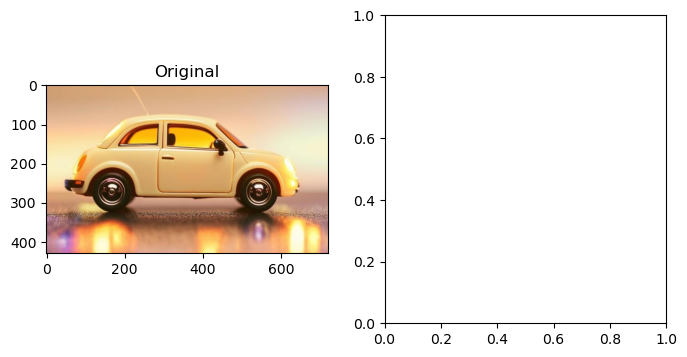

In [218]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('my_car.jpeg')

# Check image shape
print("Image Shape:", img.shape)

h, w = img.shape[:2]

# Define crop area safely inside image
row_start = int(h * 0.5)
row_end   = int(h * 0.3)
col_start = int(w * 0.4)
col_end   = int(w * 0.5)

cropped = img[row_start:row_end, col_start:col_end]

# Display
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
plt.title("Cropped")

plt.show()


### Translation : means shifting the image

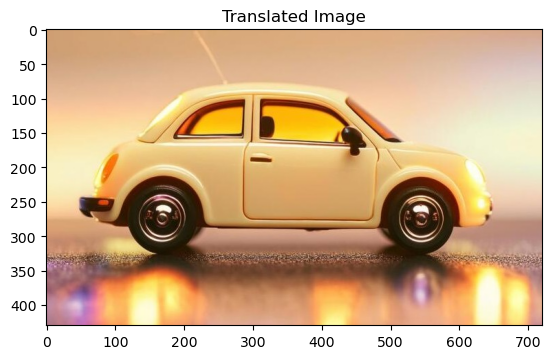

In [228]:
img = cv2.imread('my_car.jpeg')

rows, cols = img.shape[:2]

M = np.float32([[1, 0, 1],
                [0, 1, 1]])

translated = cv2.warpAffine(img, M, (cols, rows))

plt.imshow(cv2.cvtColor(translated, cv2.COLOR_BGR2RGB))
plt.title("Translated Image")
plt.show()

### Rotation of Image

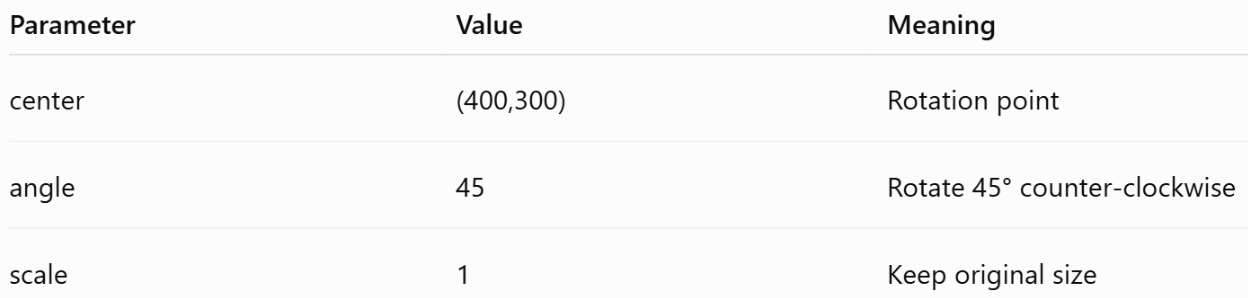

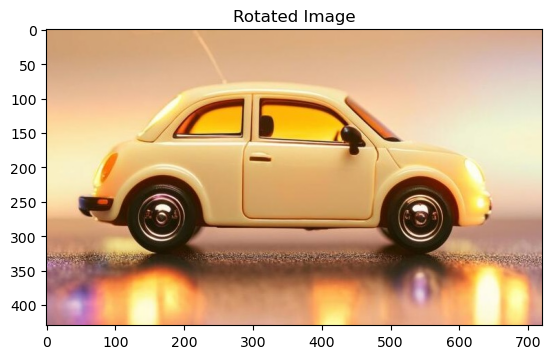

In [238]:
center = (cols//2, rows//2)

M = cv2.getRotationMatrix2D(center, 0, 1)

rotated = cv2.warpAffine(img, M, (cols, rows))

plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
plt.title("Rotated Image")
plt.show()

### Drawing on image

     1. rectangle
     2. circle
     3. line
     4. text
    

In [242]:
img.shape

(430, 721, 3)

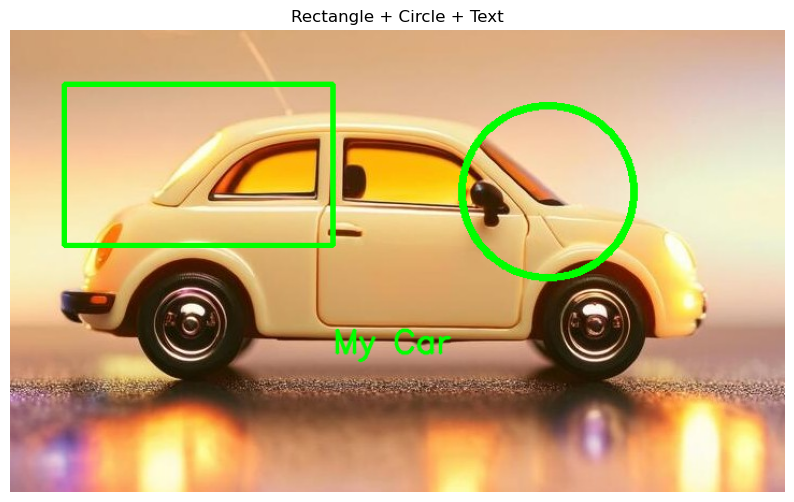

In [248]:
# Drawing Shapes on Images

import cv2
import matplotlib.pyplot as plt

# Read image
img = cv2.imread('my_car.jpeg')

# Draw Rectangle
cv2.rectangle(
    img,
    (50, 50),      # top-left
    (300, 200),    # bottom-right
    (0, 255, 0),   # Green (BGR)
    3              # Thickness
)

# Draw Circle
cv2.circle(
    img,
    (500, 150),    # Center
    80,            # Radius
    (0, 255, 0),   # Blue (BGR)
    6              # Thickness
)

# Add Text
cv2.putText(
    img,
    "My Car",
    (300, 300),                    # Position
    cv2.FONT_HERSHEY_SIMPLEX,      # Font
    1,                             # Font Scale
    (0, 255, 0),                   # Red (BGR)
    2,                             # Thickness
    cv2.LINE_AA                    # Smooth Text
)

# Display Image
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Rectangle + Circle + Text")
plt.show()

### Creating Black , White Images

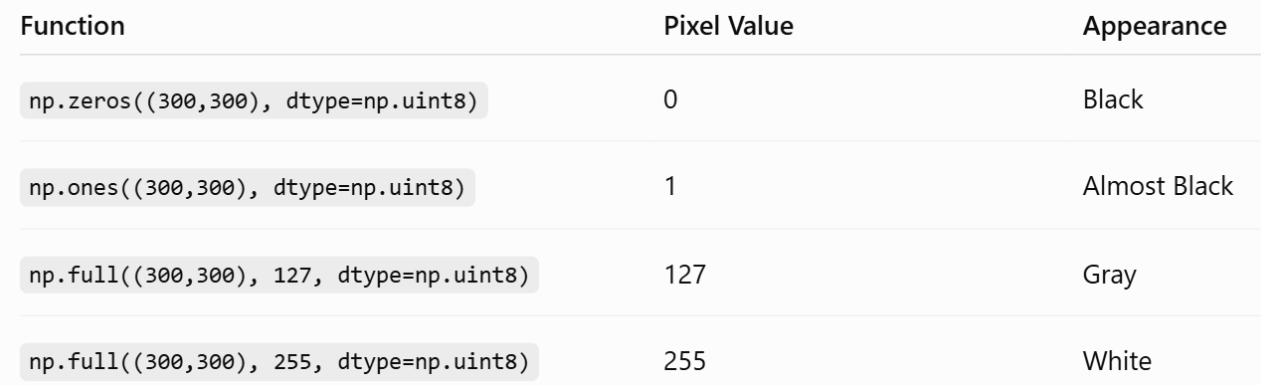

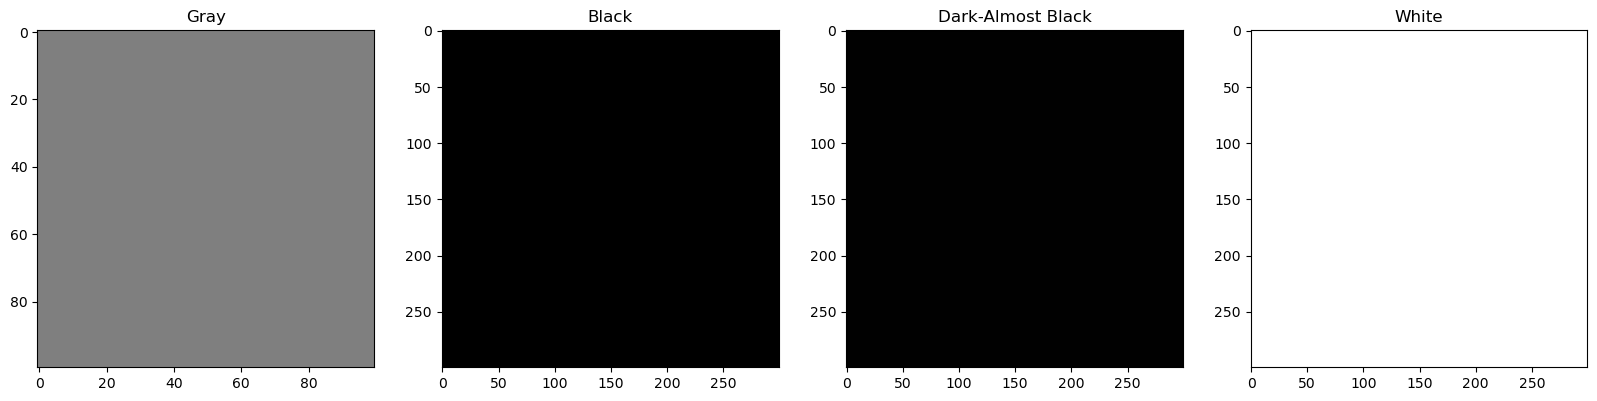

In [252]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

black = np.zeros((300,300), dtype=np.uint8)
dark = np.ones((300,300), dtype=np.uint8)
white = np.full((300,300), 255, dtype=np.uint8)
gray = np.full((100,100), 127, dtype=np.uint8)

plt.figure(figsize=(20,5))

plt.subplot(1,4,1)
plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))
plt.title("Gray")

plt.subplot(1,4,2)
plt.imshow(cv2.cvtColor(black, cv2.COLOR_BGR2RGB))
plt.title("Black")

plt.subplot(1,4,3)
plt.imshow(cv2.cvtColor(dark, cv2.COLOR_BGR2RGB))
plt.title("Dark-Almost Black")

plt.subplot(1,4,4)
plt.imshow(cv2.cvtColor(white, cv2.COLOR_BGR2RGB))
plt.title("White")

plt.show()


### Bitwise operator on images

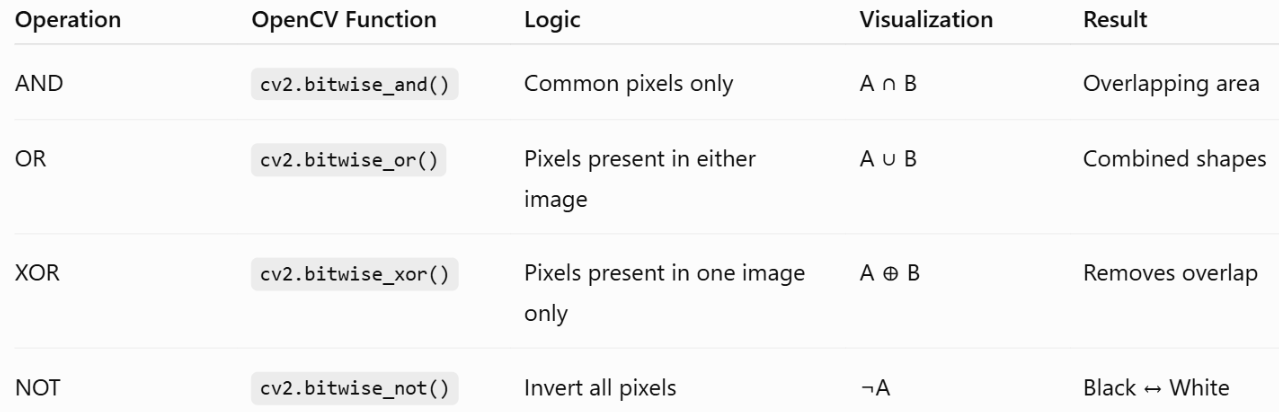

#### Here we have created two black image and then created , rectangle on 1st and circle on 2nd and then performed bitwise operation

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
			
# create two simple black picture 
img1 = np.zeros((300, 300), dtype=np.uint8)
img2 = np.zeros((300, 300), dtype=np.uint8)


# created rectangle on image1
cv2.rectangle(img1, (50, 50), (200, 200), 255, -1)

# created circle on Image2
cv2.circle(img2, (150, 150), 100, 255, -1)
			
bit_and = cv2.bitwise_and(img1, img2)
bit_or = cv2.bitwise_or(img1, img2)
bit_xor = cv2.bitwise_xor(img1, img2)
bit_not = cv2.bitwise_not(img2)
			
titles = ["Image 1", "Image 2", "AND", "OR", "XOR", "NOT"]

images = [img1, img2, bit_and, bit_or, bit_xor, bit_not]

for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')



  


In [ ]:
import cv2
import numpy as np

# ----------------------------
# Load Image
# ----------------------------
path = input("Enter image path: ")

img = cv2.imread(path)
img = cv2.resize(img,(1000,700))
if img is None:
    print("Image not found!")
    exit()

current = img.copy()


def show():
    cv2.imshow("Image Editor", current)
    cv2.waitKey(0)
    cv2.destroyAllWindows()


while True:

    print("\n========== IMAGE EDITOR ==========")
    print("1. Display Image")
    print("2. Convert to Grayscale")
    print("3. Convert to HSV")
    print("4. Resize")
    print("5. Flip")
    print("6. Crop")
    print("7. Translate")
    print("8. Rotate")
    print("9. Draw Rectangle")
    print("10. Draw Circle")
    print("11. Add Text")
    print("12. Brightness")
    print("13. Contrast")
    print("14. Bitwise Circular Mask")
    print("15. Reset")
    print("16. Save")
    print("17. Exit")

    choice = int(input("Enter Choice : "))

    # -----------------------------------
    if choice == 1:

        show()

    # -----------------------------------
    elif choice == 2:

        gray = cv2.cvtColor(current, cv2.COLOR_BGR2GRAY)
        cv2.imshow("Gray", gray)
        cv2.waitKey(0)
        cv2.destroyAllWindows()

    # -----------------------------------
    elif choice == 3:

        hsv = cv2.cvtColor(current, cv2.COLOR_BGR2HSV)
        cv2.imshow("HSV", hsv)
        cv2.waitKey(0)
        cv2.destroyAllWindows()

    # -----------------------------------
    elif choice == 4:

        w = int(input("Width : "))
        h = int(input("Height: "))

        current = cv2.resize(current, (w, h))

        show()

    # -----------------------------------
    elif choice == 5:

        print("0 = Vertical")
        print("1 = Horizontal")
        print("-1 = Both")

        flip = int(input())

        current = cv2.flip(current, flip)

        show()

    # -----------------------------------
    elif choice == 6:

        x = int(input("Start X : "))
        y = int(input("Start Y : "))
        w = int(input("Width   : "))
        h = int(input("Height  : "))

        current = current[y:y+h, x:x+w]

        show()

    # -----------------------------------
    elif choice == 7:

        tx = int(input("Shift X : "))
        ty = int(input("Shift Y : "))

        M = np.float32([[1,0,tx],[0,1,ty]])

        current = cv2.warpAffine(current, M,
                                 (current.shape[1],
                                  current.shape[0]))

        show()

    # -----------------------------------
    elif choice == 8:

        angle = float(input("Angle : "))

        h,w = current.shape[:2]

        center = (w//2,h//2)

        M = cv2.getRotationMatrix2D(center,
                                    angle,
                                    1)

        current = cv2.warpAffine(current,
                                 M,
                                 (w,h))

        show()

    # -----------------------------------
    elif choice == 9:

        x1 = int(input("x1 : "))
        y1 = int(input("y1 : "))
        x2 = int(input("x2 : "))
        y2 = int(input("y2 : "))

        cv2.rectangle(current,
                      (x1,y1),
                      (x2,y2),
                      (0,255,0),
                      3)

        show()

    # -----------------------------------
    elif choice == 10:

        x = int(input("Center X : "))
        y = int(input("Center Y : "))
        r = int(input("Radius : "))

        cv2.circle(current,
                   (x,y),
                   r,
                   (255,0,0),
                   3)

        show()

    # -----------------------------------
    elif choice == 11:

        text = input("Text : ")

        x = int(input("X : "))
        y = int(input("Y : "))

        cv2.putText(current,
                    text,
                    (x,y),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1,
                    (0,0,255),
                    2)

        show()

    # -----------------------------------
    elif choice == 12:

        beta = int(input("Brightness (-100 to 100): "))

        current = cv2.convertScaleAbs(current,
                                      alpha=1,
                                      beta=beta)

        show()

    # -----------------------------------
    elif choice == 13:

        alpha = float(input("Contrast (1-3): "))

        current = cv2.convertScaleAbs(current,
                                      alpha=alpha,
                                      beta=0)

        show()

    # -----------------------------------
    elif choice == 14:

        h,w = current.shape[:2]

        mask = np.zeros((h,w),
                        dtype=np.uint8)

        center = (w//2,h//2)

        radius = min(h,w)//3

        cv2.circle(mask,
                   center,
                   radius,
                   255,
                   -1)

        result = cv2.bitwise_and(current,
                                 current,
                                 mask=mask)

        cv2.imshow("Masked", result)
        cv2.waitKey(0)
        cv2.destroyAllWindows()

    # -----------------------------------
    elif choice == 15:

        current = img.copy()

        print("Image Reset.")

    # -----------------------------------
    elif choice == 16:

        name = input("Output filename : ")

        cv2.imwrite(name,current)

        print("Image Saved.")

    # -----------------------------------
    elif choice == 17:

        print("Thank You!")
        break

    else:

        print("Invalid Choice")

Enter image path:  C:\Users\Dell\OneDrive\Desktop\Innomatics\5_day_Workshop\lux_car.png



========== IMAGE EDITOR ==========
1. Display Image
2. Convert to Grayscale
3. Convert to HSV
4. Resize
5. Flip
6. Crop
7. Translate
8. Rotate
9. Draw Rectangle
10. Draw Circle
11. Add Text
12. Brightness
13. Contrast
14. Bitwise Circular Mask
15. Reset
16. Save
17. Exit


Enter Choice :  16
Output filename :  xyz.jpeg


Image Saved.

========== IMAGE EDITOR ==========
1. Display Image
2. Convert to Grayscale
3. Convert to HSV
4. Resize
5. Flip
6. Crop
7. Translate
8. Rotate
9. Draw Rectangle
10. Draw Circle
11. Add Text
12. Brightness
13. Contrast
14. Bitwise Circular Mask
15. Reset
16. Save
17. Exit
